# Garbage Classification Model

 **Classifying images of garbage into predefined categories: Paper, Trash, Metal, Cardboard, Glass, Plastic** 
 
The main goal of this project is to compare the performance of a **custom Convolutional Neural Network (CNN)** with a **pre-trained ResNet50** model on the Garbage Classification dataset.

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import random
from collections import defaultdict
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import copy


random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device} for inference")

Using cuda for inference


# Dataset Loading and Initial Exploration

In [4]:
#Change the path accordingly, This path for current system.
img_dir = 'D:\\Minor1_GCModel\\Garbage_Classification_Model\\Garbage_classification_Dataset'
class_names = [entry for entry in os.listdir(img_dir) if os.path.isdir(os.path.join(img_dir, entry))]
num_classes = len(class_names)

train_dir = 'D:\\Minor1_GCModel\\Garbage_Classification_Model\\one-indexed-files-notrash_train.txt'
test_dir = 'D:\\Minor1_GCModel\\Garbage_Classification_Model\\one-indexed-files-notrash_test.txt'
val_dir = 'D:\\Minor1_GCModel\\Garbage_Classification_Model\\one-indexed-files-notrash_val.txt'

df_train = pd.read_csv(train_dir, sep = ' ', header = None, names = ['path', 'label'])
df_test = pd.read_csv(test_dir, sep = ' ', header = None, names = ['path', 'label'])
df_val = pd.read_csv(val_dir, sep = ' ', header = None, names = ['path', 'label'])

print(f"Found {len(df_train)} training images, {len(df_test)} test images, {len(df_val)} validation images")
print(f"Found {num_classes} classes: {class_names}")

Found 1768 training images, 431 test images, 328 validation images
Found 6 classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [5]:
image_counts = {}

for class_name in class_names:
    class_path = os.path.join(img_dir, class_name)
    num_images = len(os.listdir(class_path))
    image_counts[class_name] = num_images
    print(f"Class: {class_name}, number of images: {num_images}")

Class: cardboard, number of images: 403
Class: glass, number of images: 501
Class: metal, number of images: 410
Class: paper, number of images: 594
Class: plastic, number of images: 482
Class: trash, number of images: 137


## Class Distribution

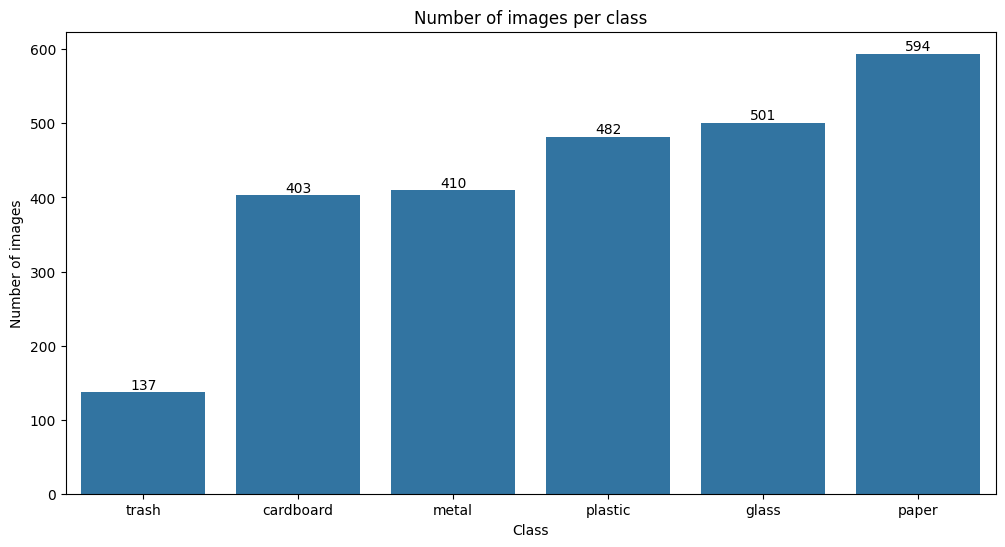

In [6]:
#Plotting the number of images per class    
df_counts = pd.DataFrame(list(image_counts.items()), columns = ['Class', 'Count'])

plt.figure(figsize = (12,6))
ax = sns.barplot(x = 'Class', y = 'Count', data = df_counts.sort_values(by = 'Count'))
plt.title('Number of images per class')
plt.xlabel('Class')
plt.ylabel('Number of images')
plt.bar_label(ax.containers[0], fontsize=10)
plt.show()

## Image Examples

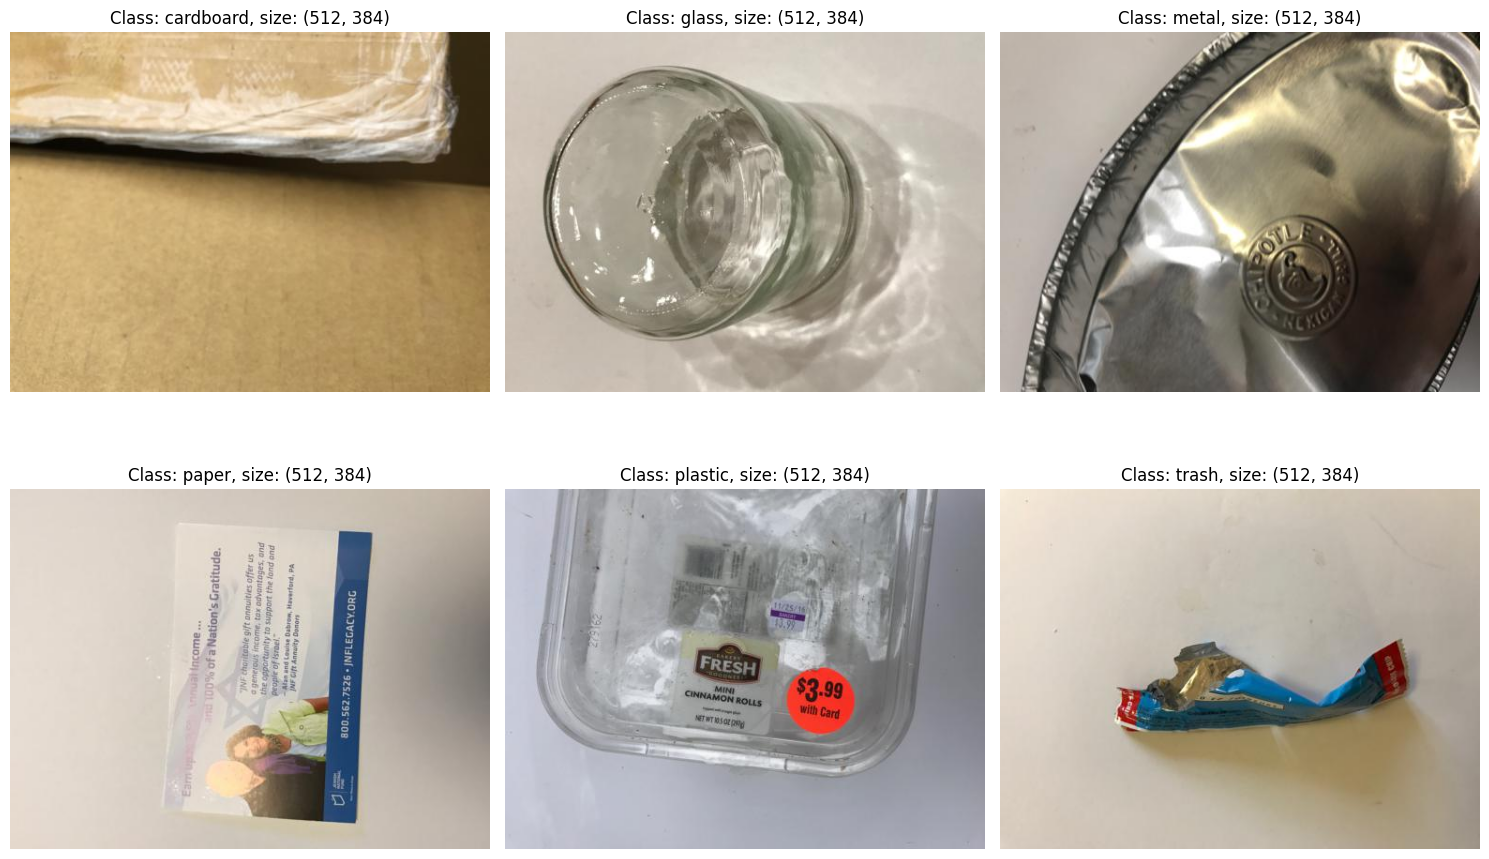

In [7]:
plt.figure(figsize = (15, 10))
for i, class_name in enumerate(class_names):
    class_path = os.path.join(img_dir, class_name)
    random_image_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, random_image_name)
    plt.subplot(2, 3, i + 1)
    img = Image.open(img_path)
    plt.imshow(img)
    plt.title(f"Class: {class_name}, size: {img.size}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## Image Sizes

In [8]:
image_sizes = defaultdict(list)

for class_name in class_names:
    class_path = os.path.join(img_dir, class_name)
    for image_name in os.listdir(class_path):
        image_path = os.path.join(class_path, image_name)
        with Image.open(image_path) as img:
            width, height = img.size
            image_sizes['width'].append(width)
            image_sizes['height'].append(height)
df_sizes = pd.DataFrame(image_sizes)

In [9]:
df_sizes.describe()

,width,height
count,2527.0,2527.0
mean,512.0,384.0
std,0.0,0.0
min,512.0,384.0
25%,512.0,384.0
50%,512.0,384.0
75%,512.0,384.0
max,512.0,384.0


All images have a size of 512x384 pixels.

# Data Preprocessing

In [10]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=30),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) #normalization parameters for resnet50
])

test_val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) #normalization parameters for resnet50
])

'''
"train_transform" include augmentations like flips and rotations, normalization, and resizing;
while "test_val_transform" includes resizing and normalization only.

This separation ensures that augmentations are applied only during training to help the model generalize,
while validation remains a fair measure of model performance.
'''

'\n"train_transform" include augmentations like flips and rotations, normalization, and resizing;\nwhile "test_val_transform" includes resizing and normalization only.\n\nThis separation ensures that augmentations are applied only during training to help the model generalize,\nwhile validation remains a fair measure of model performance.\n'

## Defining DataSet and DataLoader

In [11]:
class_map = {
    1: 'glass',
    2: 'paper',
    3: 'cardboard',
    4: 'plastic',
    5: 'metal',
    6: 'trash'
}

class GarbageDataset(Dataset):
    def __init__(self, df, img_dir,transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)


    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        folder = class_map[int(row['label'])]
        filename = row['path']
        img_path = os.path.join(self.img_dir, folder, filename)
        image = Image.open(img_path)
        label = int(row['label']) - 1
        if self.transform:
            image = self.transform(image)
        return image, label

In [12]:
train_dataset = GarbageDataset(df_train, img_dir, transform=train_transform)
val_dataset = GarbageDataset(df_val, img_dir, transform=test_val_transform)
test_dataset = GarbageDataset(df_test, img_dir, transform=test_val_transform)

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

In [13]:
images, labels = next(iter(train_loader))
print(images.shape, labels.shape)

torch.Size([32, 3, 224, 224]) torch.Size([32])


Testing the results of data preprocessing

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4285715].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2914162].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.0434172].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5528543].
Clippin

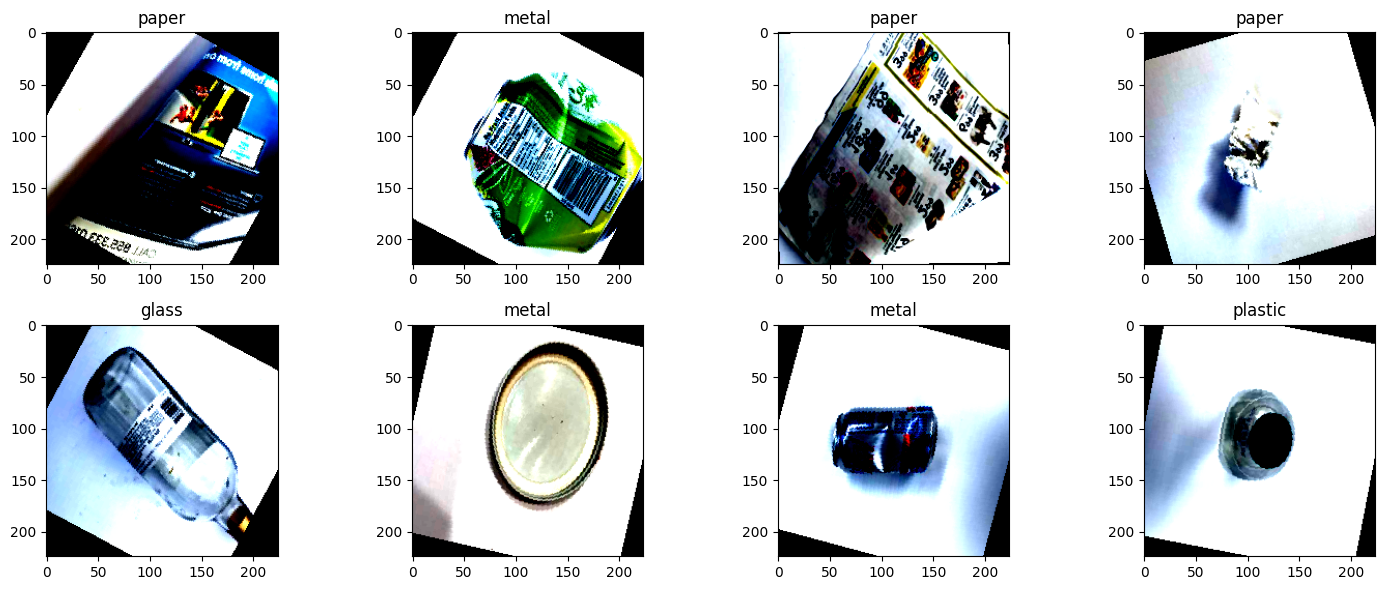

In [14]:
class_names = [class_map[i+1] for i in range(len(class_map))]
images, labels = next(iter(train_loader))
plt.figure(figsize=(15, 6))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.imshow(images[i].numpy().transpose((1, 2, 0)))
    label_idx = labels[i].item()
    plt.title(class_names[label_idx])
plt.tight_layout()
plt.show()

# Model Building
## Custom Convolutional Neural Network (CNN)

In [15]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes):
        super(CustomCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(128 * 28 * 28, 256)
        self.fc2 = nn.Linear (256, num_classes)

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        x = self.pool(torch.relu(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [16]:
customcnn = CustomCNN(num_classes=num_classes)

In [17]:
customcnn = customcnn.to(device)

## Transfer Learning with ResNet50

In [18]:
resnet50 = models.resnet50(weights='DEFAULT')

In [19]:
#transfer learning
#Note: Not to update weights in hidden layers.
for param in resnet50.parameters():
    param.required_grad = False

In [20]:
num_features = resnet50.fc.in_features


In [21]:
resnet50.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, num_classes)
)

In [22]:
resnet50 = resnet50.to(device)

## Defining class weights

In [23]:
ordered_classes = [class_map[i] for i in range(1, num_classes + 1)]
df_counts_sorted = df_counts.set_index('Class').loc[ordered_classes].reset_index()
class_counts = df_counts_sorted['Count'].tolist()
print(class_counts)

[501, 594, 403, 482, 410, 137]


In [24]:
class_counts = torch.tensor(class_counts, dtype=torch.float32)

In [25]:
weights = class_counts.sum() / (len(class_counts) * class_counts)
weights = weights / weights.sum() * len(class_counts)
weights = weights.to(device)

In [26]:
criterion = nn.CrossEntropyLoss(weight=weights)

## Forward Pass Test

Before training is started, a forward pass test is performed on a small batch of data.


In [27]:
# testing forward pass of first batch
images, labels = next(iter(train_loader))
print("Input shape:", images.shape)
print("Labels shape:", labels.shape)

images = images.to(device)
labels = labels.to(device)

outputs = customcnn(images)
print("Output shape:", outputs.shape)

loss = criterion(outputs, labels)
print("Loss (first batch):", loss.item())

Input shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Output shape: torch.Size([32, 6])
Loss (first batch): 1.8140467405319214


# Model Training and Evaluation


At the end of training, the two models (custom CNN vs pre-trained ResNet50) are compared to determine which approach is performed better on the garbage classification task.

In [28]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=20):
    best_model = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []
    
    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-'*50)
        #training
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad() #gradients to zero to avoid accumulation
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step() #single optimization step to update parameter

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        #validation
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_loss / val_total
        val_acc = val_correct / val_total
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        print(f'Train loss: {train_loss:.4f}, accuracy: {train_acc:.4f}')
        print(f'  Val loss: {val_loss:.4f}, accuracy: {val_acc:.4f}')

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model = copy.deepcopy(model.state_dict())
            print("Best model updated.")

    print(f'Training complete. Best validation accuracy: {best_val_acc:.4f}')
    model.load_state_dict(best_model)
    return model, {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accuracies': train_accuracies,
        'val_accuracies': val_accuracies
    }

In [29]:
if torch.cuda.device_count() > 1:
    customcnn = nn.DataParallel(customcnn)

In [30]:
num_epochs = 50
optimizer = optim.Adam(customcnn.parameters(), lr=0.001)  #Using Adam optimizer

customcnn_model, customcnn_history = train_model(
    customcnn,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    num_epochs=num_epochs,
)

Epoch 1/50
--------------------------------------------------
Train loss: 9.0239, accuracy: 0.3043
  Val loss: 1.6474, accuracy: 0.3415
Best model updated.
Epoch 2/50
--------------------------------------------------
Train loss: 1.4522, accuracy: 0.4434
  Val loss: 1.3710, accuracy: 0.5244
Best model updated.
Epoch 3/50
--------------------------------------------------
Train loss: 1.3321, accuracy: 0.4966
  Val loss: 1.2894, accuracy: 0.5366
Best model updated.
Epoch 4/50
--------------------------------------------------
Train loss: 1.2559, accuracy: 0.5238
  Val loss: 1.3160, accuracy: 0.5610
Best model updated.
Epoch 5/50
--------------------------------------------------
Train loss: 1.1483, accuracy: 0.5707
  Val loss: 1.1847, accuracy: 0.6037
Best model updated.
Epoch 6/50
--------------------------------------------------
Train loss: 1.1132, accuracy: 0.5730
  Val loss: 1.1788, accuracy: 0.6098
Best model updated.
Epoch 7/50
--------------------------------------------------
Tr

In [31]:
if torch.cuda.device_count() > 1:
    resnet50 = nn.DataParallel(resnet50)

In [32]:
num_epochs = 25
optimizer = optim.Adam(resnet50.parameters(), lr=0.001) #Using Adam optimizer

resnet50_model, resnet50_history = train_model(
    resnet50,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    num_epochs=num_epochs,
)

Epoch 1/25
--------------------------------------------------
Train loss: 1.2601, accuracy: 0.5730
  Val loss: 1.2121, accuracy: 0.5152
Best model updated.
Epoch 2/25
--------------------------------------------------
Train loss: 0.9403, accuracy: 0.6850
  Val loss: 1.1049, accuracy: 0.6067
Best model updated.
Epoch 3/25
--------------------------------------------------
Train loss: 0.7036, accuracy: 0.7523
  Val loss: 0.7230, accuracy: 0.7591
Best model updated.
Epoch 4/25
--------------------------------------------------
Train loss: 0.6462, accuracy: 0.7805
  Val loss: 1.0552, accuracy: 0.5884
Epoch 5/25
--------------------------------------------------
Train loss: 0.5478, accuracy: 0.8060
  Val loss: 0.8534, accuracy: 0.7348
Epoch 6/25
--------------------------------------------------
Train loss: 0.4595, accuracy: 0.8371
  Val loss: 0.4890, accuracy: 0.8506
Best model updated.
Epoch 7/25
--------------------------------------------------
Train loss: 0.3763, accuracy: 0.8705
  Val

In [33]:
def evaluate_model(model, test_loader, device, class_names):
    model.eval()
    all_predictions = []
    all_labels = []
    all_probabilities = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probabilities = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)

            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_predictions)
    precision = precision_score (all_labels, all_predictions, average='weighted')
    recall = recall_score(all_labels, all_predictions, average='weighted')
    f1 = f1_score(all_labels, all_predictions, average='weighted')
    cm = confusion_matrix(all_labels, all_predictions)

    return {
        'predictions': all_predictions,
        'labels': all_labels,
        'probabilities': all_probabilities,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'confusion_matrix': cm
    }

In [34]:
def plot_loss_acc_curves(history, model_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,5))

    #loss
    ax1.plot(history['train_losses'], label='Train Loss', color='blue')
    ax1.plot(history['val_losses'], label='Validation Loss', color='orange')
    ax1.set_title(f'{model_name} - Loss Curve')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_yticks(np.arange(0, 7, 0.5))
    ax1.legend()
    ax1.grid(True)

    #accuracy
    ax2.plot(history['train_accuracies'], label='Train Accuracy', color='blue')
    ax2.plot(history['val_accuracies'], label='Validation Accuracy', color='orange')
    ax2.set_title(f'{model_name} - Accuracy Curve')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_yticks(np.arange(0, 1.1, 0.1))
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

In [35]:
customcnn_results = evaluate_model(customcnn_model, test_loader, device, class_names)
resnet_results = evaluate_model(resnet50_model, test_loader, device, class_names)

models_results = {
    'CustomCNN': customcnn_results,
    'ResNet50': resnet_results
}

<Figure size 400x400 with 0 Axes>

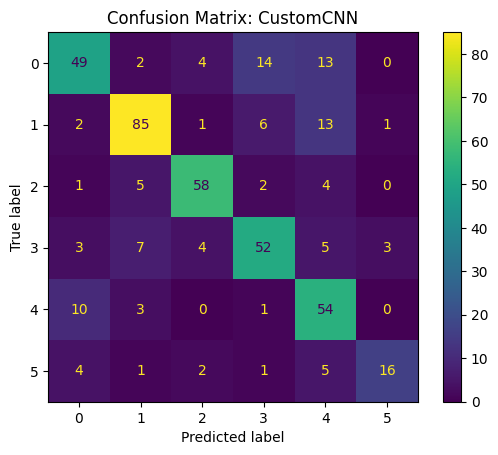

<Figure size 400x400 with 0 Axes>

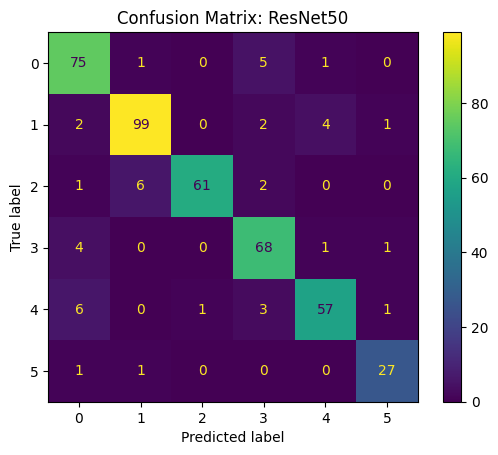

In [36]:
for model_name, results in models_results.items():
    cm = results['confusion_matrix']
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    plt.figure(figsize=(4, 4))
    disp.plot()
    plt.title(f'Confusion Matrix: {model_name}')
    plt.grid(False)
    plt.show()

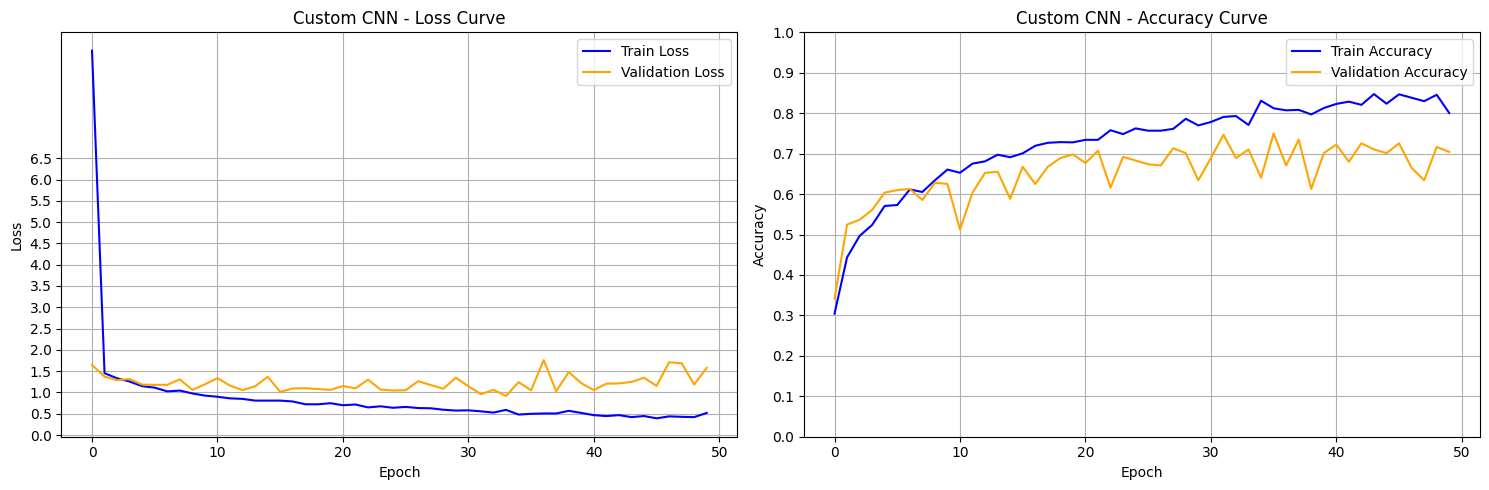

In [37]:
plot_loss_acc_curves(customcnn_history, 'Custom CNN')


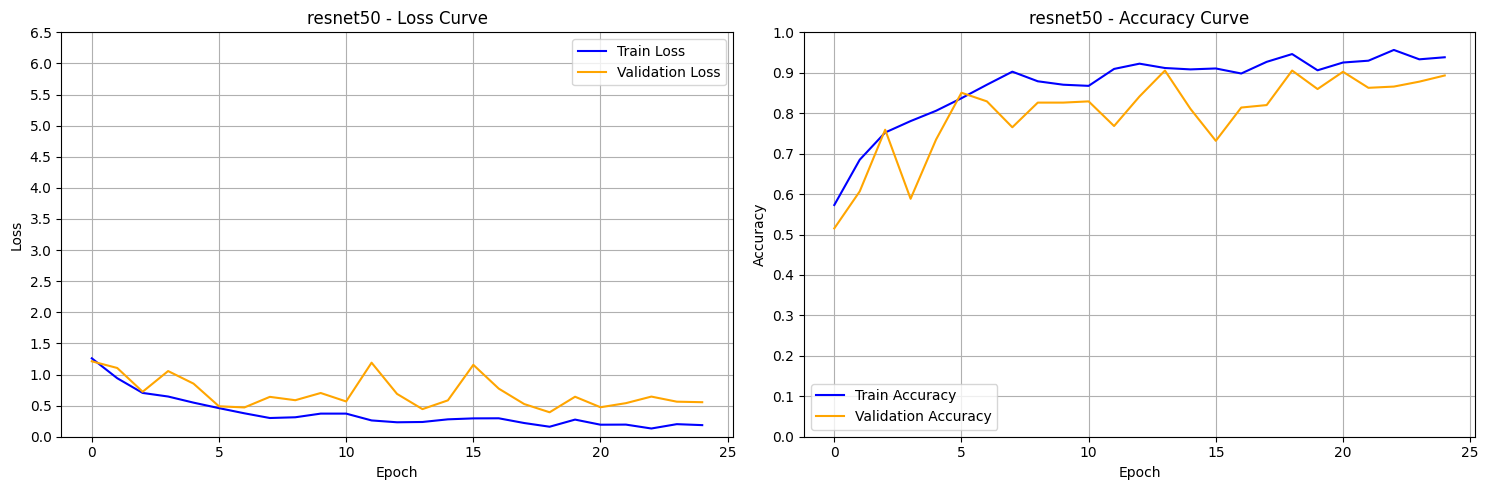

In [38]:
plot_loss_acc_curves(resnet50_history, 'resnet50')

    

In [39]:
def create_comparison_table(results_dict):
    comparison_data = []
    
    for model_name, results in results_dict.items():
        comparison_data.append({
            'Model': model_name,
            'Accuracy': f"{results['accuracy']:.4f}",
            'Precision': f"{results['precision']:.4f}",
            'Recall': f"{results['recall']:.4f}",
            'F1-Score': f"{results['f1_score']:.4f}"
        })
    
    df_comparison = pd.DataFrame(comparison_data)
    return df_comparison

In [40]:
comparison_df = create_comparison_table(models_results)
print("Models Comparison:")
print("-" * 50)
print(comparison_df.to_string(index=False))

Models Comparison:
--------------------------------------------------
    Model Accuracy Precision Recall F1-Score
CustomCNN   0.7285    0.7404 0.7285   0.7291
 ResNet50   0.8979    0.9012 0.8979   0.8983


In [41]:
def denormalize(tensor, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    mean = torch.tensor(mean).view(-1, 1, 1)
    std = torch.tensor(std).view(-1, 1, 1)
    return tensor * std + mean

def show_examples_grid(examples, title, denormalize_fn, rows=2, cols=4, incorrect=False):
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    fig.suptitle(title, fontsize=16)

    for ax, example in zip(axes.flat, examples):
        img = denormalize_fn(example['image'].clone()).permute(1, 2, 0).numpy()
        ax.imshow(img)
        if incorrect:
            ax.set_title(f"True: {example['true_class']}\nPred: {example['pred_class']}", color='red')
        else:
            ax.set_title(f"Class: {example['true_class']}")
        ax.axis('off')

    for ax in axes.flat[len(examples):]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

def show_classification_examples(model, test_loader, device, class_names, num_examples=8):
    model.eval()
    correct_examples = []
    incorrect_examples = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            for img, true, pred in zip(images, labels, predicted):
                if len(correct_examples) >= num_examples and len(incorrect_examples) >= num_examples:
                    break

                true_label = true.item()
                pred_label = pred.item()
                example = {
                    'image': img.cpu(),
                    'true_label': true_label,
                    'pred_label': pred_label,
                    'true_class': class_names[true_label],
                    'pred_class': class_names[pred_label]
                }

                if true_label == pred_label and len(correct_examples) < num_examples:
                    correct_examples.append(example)
                elif true_label != pred_label and len(incorrect_examples) < num_examples:
                    incorrect_examples.append(example)

            if len(correct_examples) >= num_examples and len(incorrect_examples) >= num_examples:
                break

    show_examples_grid(correct_examples, "Correct Classifications", denormalize_fn=denormalize)
    show_examples_grid(incorrect_examples, "Incorrect Classifications", denormalize_fn=denormalize, incorrect=True)


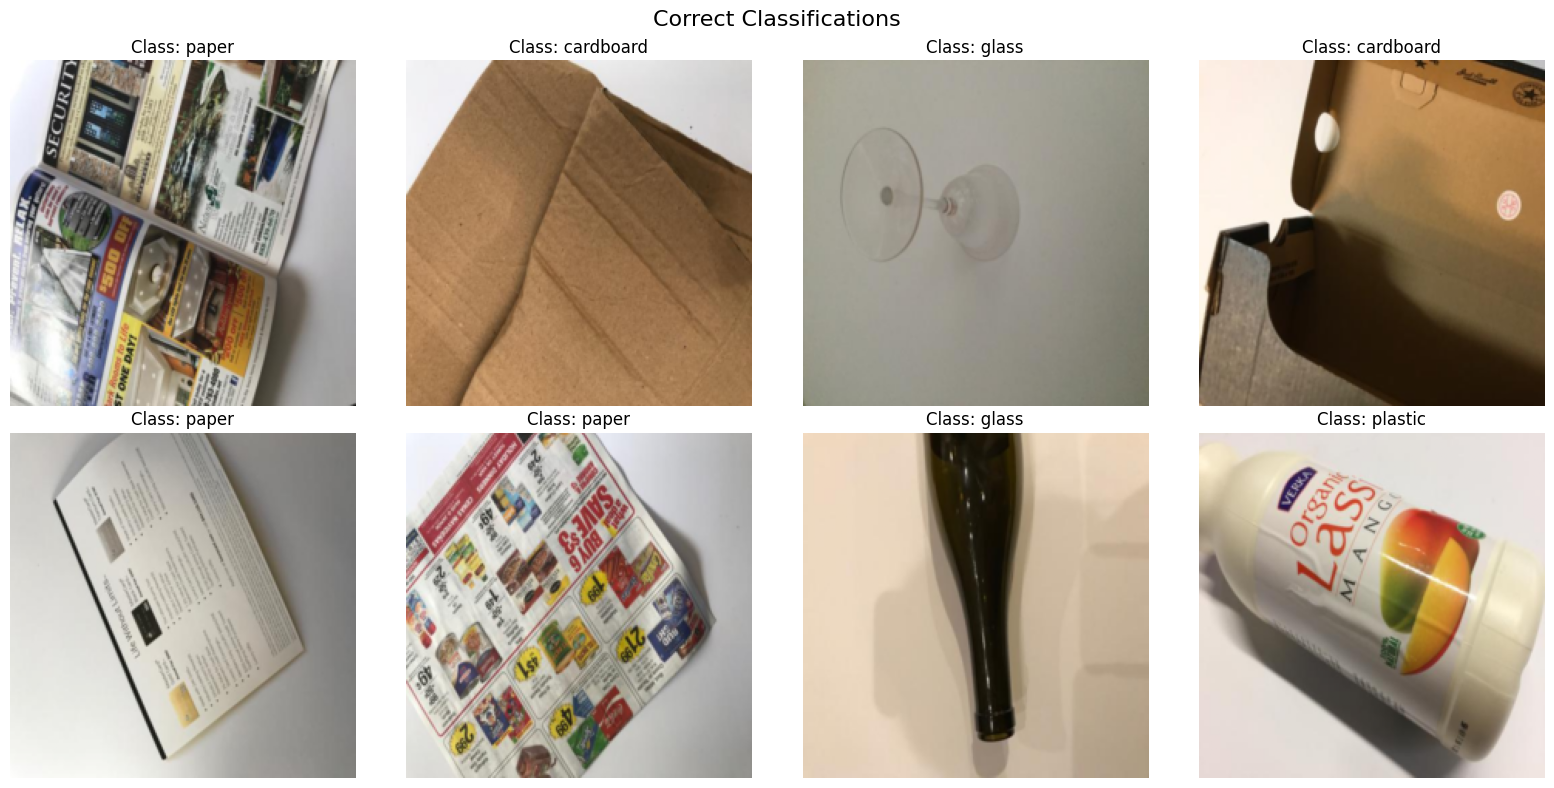

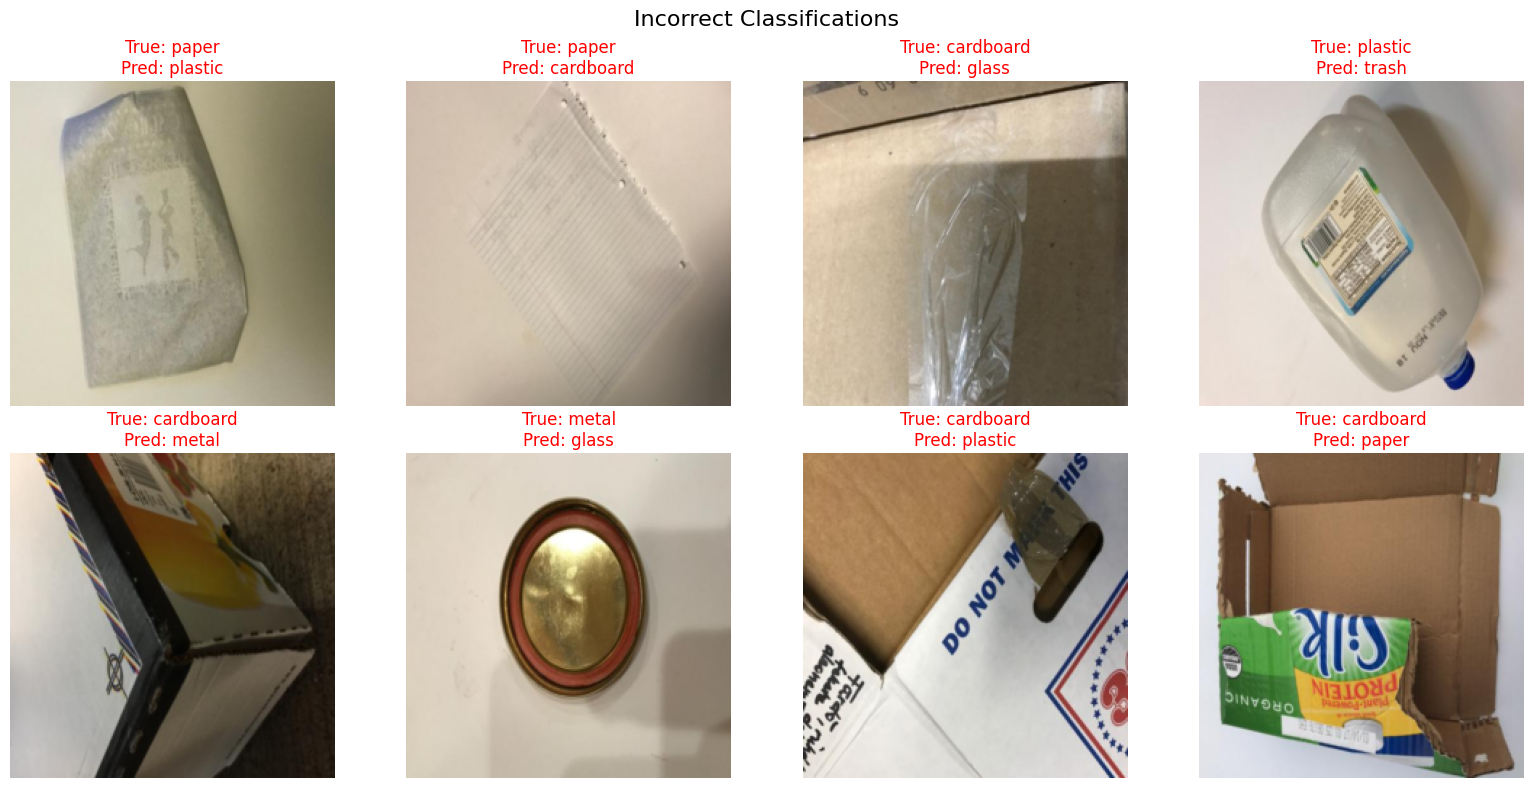

In [42]:
show_classification_examples(customcnn_model, test_loader, device, class_names, num_examples=8)

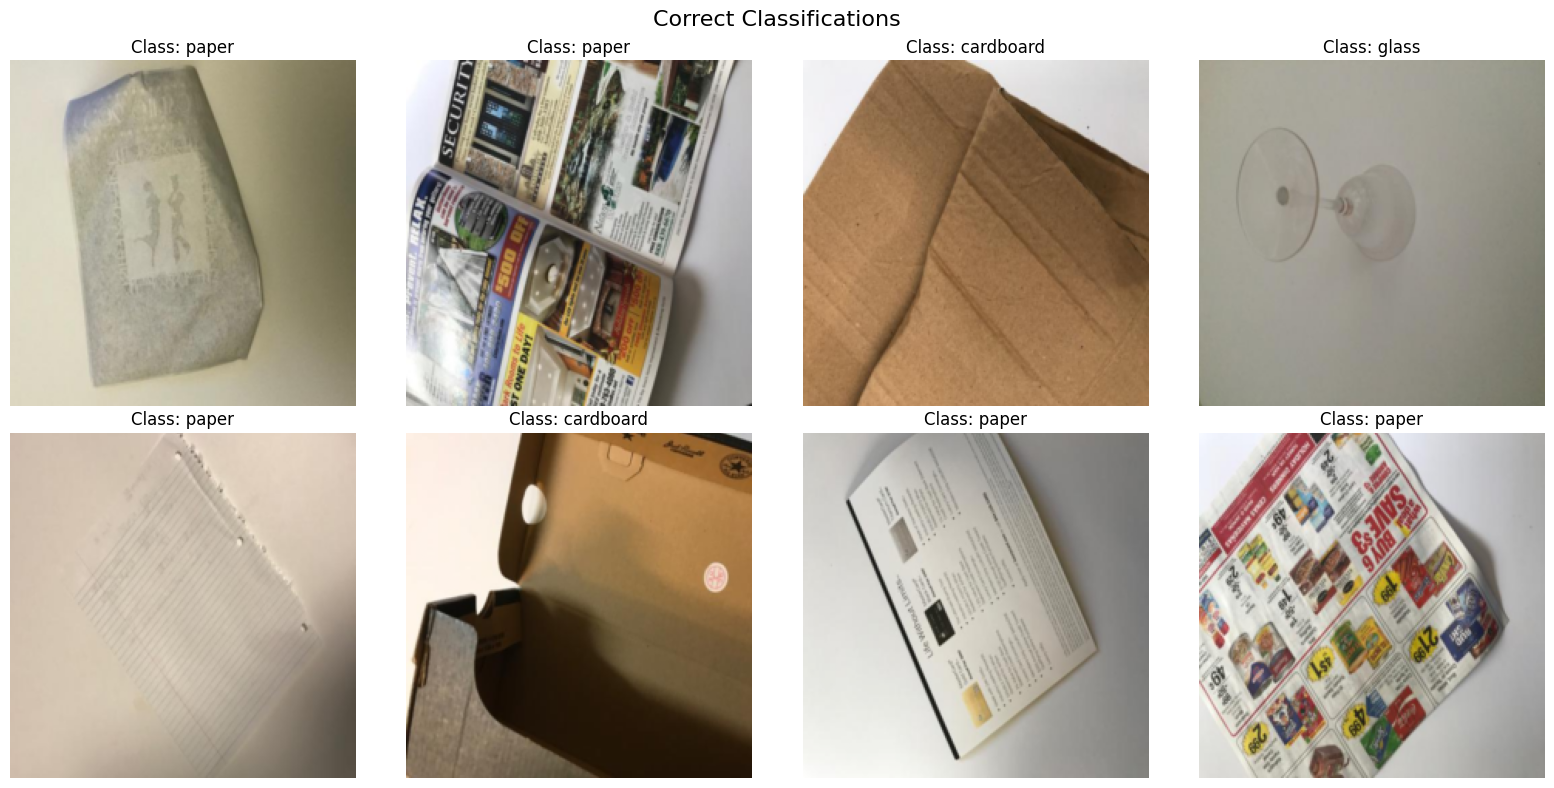

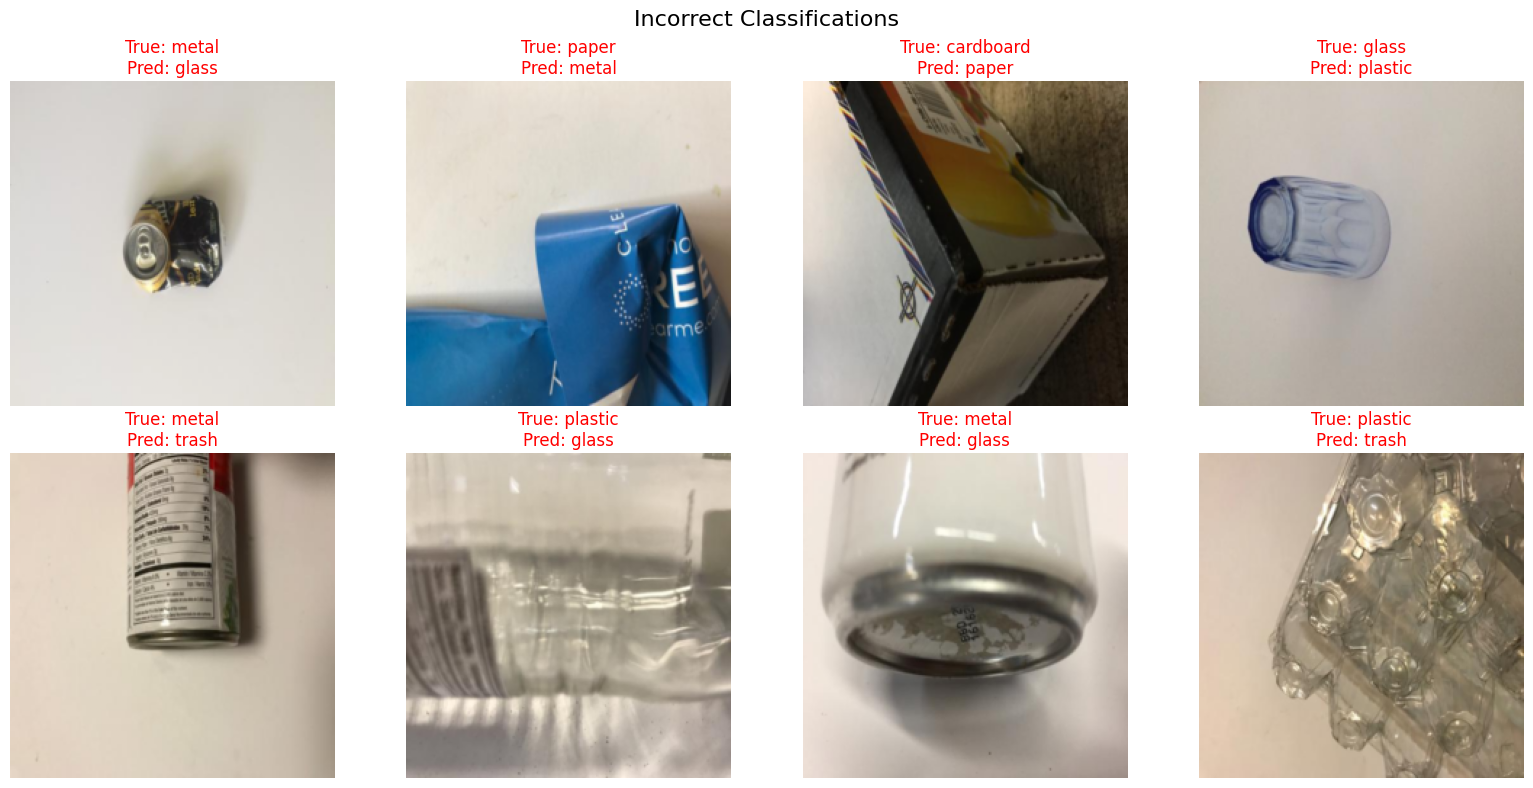

In [43]:
show_classification_examples(resnet50_model, test_loader, device, class_names, num_examples=8)


## Working Demo (Image -> Prediction)

This section shows the live working demo of the model. New Trash Image to be classified is feed to the model and the model classifies this into category.


In [47]:
import io
from PIL import Image
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Choose model to use for the demo:resnet50_model, customcnn_model
try:
    demo_model = resnet50_model  #  default (if available)
except NameError:
    demo_model = None

if demo_model is None:
    try:
        demo_model = customcnn_model
    except NameError:
        demo_model = None

assert demo_model is not None, "No trained model found (resnet50_model or customcnn_model)."
assert 'class_names' in globals(), "class_names not found."
assert 'test_val_transform' in globals(), "test_val_transform not found."
device_model = next(demo_model.parameters()).device
demo_model.eval()

def predict_image_pil(pil_img, model=demo_model, transform=test_val_transform, class_names=class_names, device=device_model, topk=3):
    """Predict class for a PIL image and return (top_indices, top_probs)."""
    with torch.no_grad():
        img = transform(pil_img).unsqueeze(0).to(device)
        logits = model(img)
        probs = F.softmax(logits, dim=1).squeeze(0)
        top_probs, top_idxs = torch.topk(probs, k=min(topk, probs.numel()))
        return top_idxs.cpu().tolist(), top_probs.cpu().tolist()

'''
def show_prediction(image_path, model=demo_model, class_names=class_names, transform=test_val_transform, device=device_model, topk=3):
    pil_img = Image.open(image_path).convert('RGB')
    top_idxs, top_probs = predict_image_pil(pil_img, model, transform, class_names, device, topk=topk)
    pred_idx = top_idxs[0]
    pred_class = class_names[pred_idx]
    pred_conf = top_probs[0]

    # Display
    plt.figure(figsize=(4,4))
    plt.imshow(pil_img)
    plt.axis('off')
    title_lines = [f"Pred: {pred_class} ({pred_conf*100:.1f}%)"]
    for i in range(1, len(top_idxs)):
        title_lines.append(f"{i+1}. {class_names[top_idxs[i]]} ({top_probs[i]*100:.1f}%)")
    plt.title("\n".join(title_lines))
    plt.show()

    return {
        "pred_class": pred_class,
        "pred_confidence": float(pred_conf),
        "topk": [(class_names[idx], float(p)) for idx, p in zip(top_idxs, top_probs)]
    }

print("1) Path-based: result = show_prediction('path/to/your_image.jpg')")

result = show_prediction("D:\\Minor1_GCModel\\Garbage_Classification_Model\\Demo_image\\test_img.jpg")
print(result)
'''

'\ndef show_prediction(image_path, model=demo_model, class_names=class_names, transform=test_val_transform, device=device_model, topk=3):\n    pil_img = Image.open(image_path).convert(\'RGB\')\n    top_idxs, top_probs = predict_image_pil(pil_img, model, transform, class_names, device, topk=topk)\n    pred_idx = top_idxs[0]\n    pred_class = class_names[pred_idx]\n    pred_conf = top_probs[0]\n\n    # Display\n    plt.figure(figsize=(4,4))\n    plt.imshow(pil_img)\n    plt.axis(\'off\')\n    title_lines = [f"Pred: {pred_class} ({pred_conf*100:.1f}%)"]\n    for i in range(1, len(top_idxs)):\n        title_lines.append(f"{i+1}. {class_names[top_idxs[i]]} ({top_probs[i]*100:.1f}%)")\n    plt.title("\n".join(title_lines))\n    plt.show()\n\n    return {\n        "pred_class": pred_class,\n        "pred_confidence": float(pred_conf),\n        "topk": [(class_names[idx], float(p)) for idx, p in zip(top_idxs, top_probs)]\n    }\n\nprint("1) Path-based: result = show_prediction(\'path/to/your_i

In [48]:
from IPython.display import display, clear_output
import ipywidgets as widgets
import io
from PIL import Image
import matplotlib.pyplot as plt

upload = widgets.FileUpload(accept='image/*', multiple=False)
out = widgets.Output()

def on_upload_change(change):
    if not upload.value:
        return
    uploaded_file = upload.value[0]
    content = uploaded_file['content']
    with out:
        clear_output(wait=True)
        img = Image.open(io.BytesIO(content)).convert('RGB')
        # Show prediction & image
        top = predict_image_pil(img)
        plt.figure(figsize=(4,4))
        plt.imshow(img)
        plt.axis('off')
        # Build title
        pred_idx = top[0][0]
        pred_conf = top[1][0]
        title = f"Pred: {class_names[pred_idx]} ({pred_conf*100:.1f}%)"
        for i in range(1, len(top[0])):
            title += f"\n{i+1}. {class_names[top[0][i]]} ({top[1][i]*100:.1f}%)"
        plt.title(title)
        plt.show()

display(widgets.VBox([widgets.HTML('<b>Upload an image to classify:</b>'), upload, out]))
upload.observe(on_upload_change, names='value')